In [18]:
import torch
from torch import nn
import matplotlib.pyplot as plt


torch.__version__

'2.13.0+cu130'

# Data preparing and loading

`Y =aX + b`

In [19]:
weight = 0.7 # weight is a parameter times with X
bias = 0.3 # bias is b a scalar


#create
start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)

y = weight * X + bias

In [20]:
X[:10],y[:10], len(X), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

## split data into training and testing set

In [21]:
split_size = int(len(X)*0.8)
X_train, y_train = X[:split_size], y[:split_size]

X_test,y_test = X[split_size:], y[split_size:]


### Visualize

In [22]:
def plot_predictions(train_data=X_train, train_labels = y_train, test_data=X_test, test_labels=y_test, predictions=None):
    plt.figure(figsize=(10,7))

    plt.scatter(train_data,train_labels, c="b", s=4,label="Training data")

    plt.scatter(test_data, test_labels, c='g', s=4,label="Test data")

    if predictions is not None:
        plt.scatter(test_data, predictions,c="r", s=4, label="Predictions")
    plt.legend(prop={"size": 14});


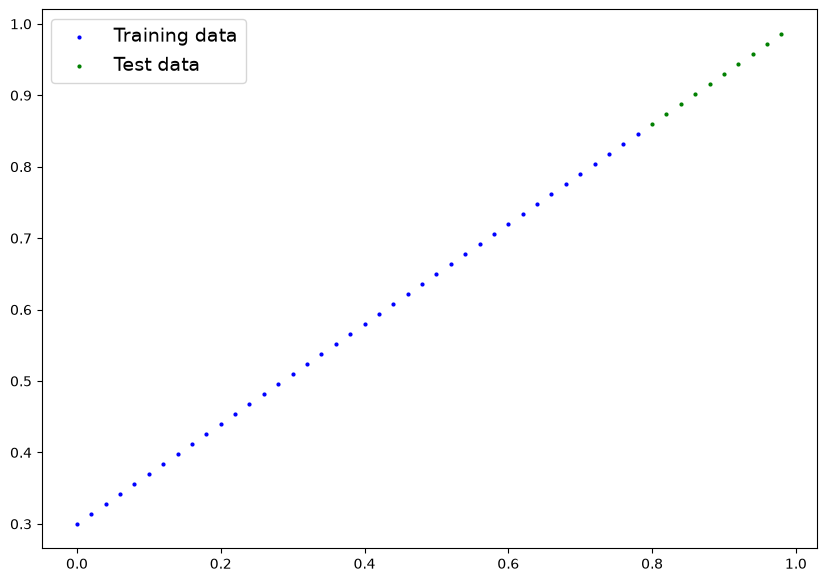

In [23]:
plot_predictions();

### Create model regression
* `Y = aX + b`
Tạo một model với các thuộc tính gồm hệ số góc là a và b là hằng số tự do
requires_grad xem ở phần auto grad https://docs.pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html
Tóm tắt dễ nhớ hàm này sẽ theo dõi các tham số yêu cầu gradient tracking nó sẽ tính toán và lưu lại ở gradient

Luồng hoạt động của mô hình:
* Sẽ tạo ngẫu nhiên các phần hệ số góc a và hằng số tự do b
* Dùng các dữ liệu mẫu ở trên để có thể tính toán và cập nhật lại các hàm số này sao cho ~ với hàm số ban đầu `f(x) ~~ Y`

Nó hoạt động qua 2 thuật toán chính:
* Gradient descent: độ dốc gradient
* Backpropagation: lan truyền ngược


In [24]:
from torch import nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

        self.bias = nn.Parameter(torch.randn(1, requires_grad=True,dtype=torch.float))

    def forward(self,x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias # Y = aX + b
        

### Pytorch model building essentials
* torch.nn: chứa tất cả các khối để xây dựng model
* torch.Parameter: quyết định tham số nào mà model sẽ thử và học thường thì torch.nn đã làm điều này rồi.
* nn.Module: là lớp cơ sở cho mọi mô hình mạng neuron nếu dùng nó sẽ cần viết lại hàm forward.
* torch.optim: Là nơi của những hàm tối ưu trong pytorch, chúng sẽ giúp cải thiện gradient descent.
* def forward(): Tất cả các lớp con dùng nn.Module cần được override lại để phù hợp cho bài toán của chúng ta.

In [25]:
torch.manual_seed(42)
torch.randn(1)

tensor([0.3367])

In [26]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()


# Checkout the parameters

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [27]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Kiểm tra phần dự đoán brin brinhhh

Giờ Kiểm tra mô hình bằng cách đưa thằng `x_test` vô -> `predictions` so sánh với `y_test` rồi tính các metrix là đẹp trai.
Khi mà nhét cái dữ liệu vô model thì vô cái nhà máy đó sẽ chạy `forward()` method để tìm f(x). 

`with torch.inference_mode()` bự hơn `with torch.no_grad()` vì ngoài tắt theo dõi gradient nó còn tắt nhiều tính năng autograd khác

In [28]:
# Make Prediction with model
with torch.inference_mode():
    y_preds = model_0(X_test)

# Một cách tương đồng với inference_mode()
with torch.no_grad():
    y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

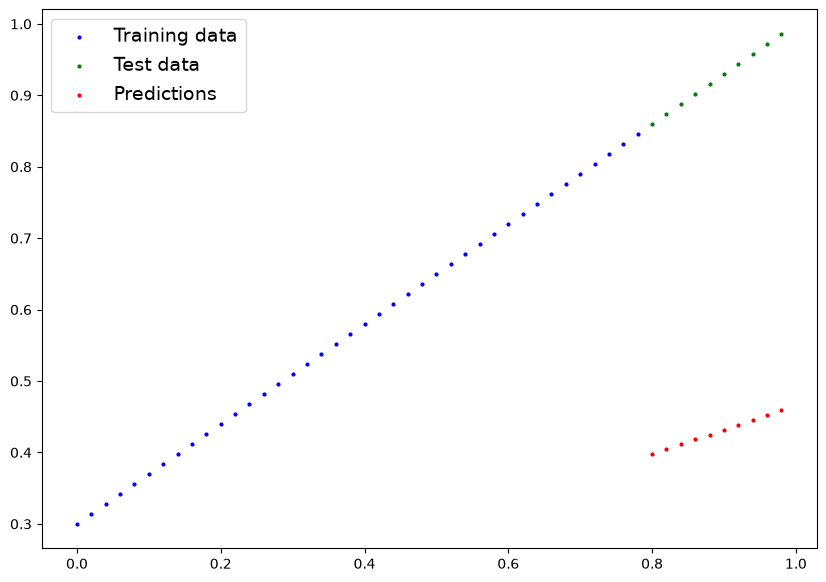

In [29]:
plot_predictions(predictions=y_preds)

## Huấn luyện model
Ý tưởng chính của việc huấn luyện mô hình là từ mô hình huấn luyện bởi các tham số không biết trước (thường là ngẫu nhiên) giờ mô hình ảnh biết trước vài anh.

Một trong những cách để biết được hiệu suất của mô hình là dùng hàm mất mát.


Những điều cần huấn luyện:
* **Loss funtion:** là một hàm tính toán how wrong the model's predictions are to ideals output càng thấp càn tốt.
* **Optimizer:** Truy cập thẳng vào trong độ mất mát (loss) của mô hình và các parameter trong trường hợp của tui là để cải thiện loss func

Thực hiện như sau:
* Training loop
* Testing loop

In [30]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [31]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [32]:
# Tạo hàm loss funtion

loss_fn = nn.L1Loss()

# Tạo optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(),
 lr=0.01) 
#lr: là learning rate cứ khoảng <1 khoảng tg (mình tự đặt)> thì sẽ tùy chỉnh lại các parameter mà mô hình đọc được trường hợp này là weights và bias



In [33]:
loss_fn

L1Loss()

### Xây dựng 1 training loop 

Đôi điều cần làm trong 1 training loop:
0. Lặp qua dữ liệu .
1. Forward pass (cho data đi qua Forward func) - và gọi lan truyền xui forward propagation.
2. Tính toán sai số (loss) - so sánh những dự đoán từ việc lan truyền xui với kết quả thực tế.
3. Optimizer zero grad
4. Loss backward -đi ngược lại từ output về input để tính gradient của mỗi parameters của mô hình với sai số (**backpropagation**)
5. Optimize step - sử dụng optimizer để điều chỉnh parameters'model để thử và cải thiện sai số (loss) (**gradient descent**)

In [34]:
torch.manual_seed(42)


epochs = 200

# Tracking useful infomation
epoch_count = []
loss_values = []
test_loss_values = []


#0. Lặp qua dữ liệu
for epoch in range(epochs):
    #Mở chế độ training cho mô hình
    model_0.train()
    
    #1. Forward pass
    y_pred = model_0(X_train)

    #2. Calculate Loss
    loss = loss_fn(y_pred,y_train)

    
    #3. Optimizer zero grad
    optimizer.zero_grad()

    #4. Perform backward propagation on the loss with
    loss.backward() 
    
    #5. Step the optimizer
    # Bình thường optimizer sẽ tính toán các gradient và chúng thuộc dạng tích lũy 
    # vì vậy cần đặt lại bộ tích lũy này sau mỗi vòng lặp để đảm bảo mỗi một sample thì sẽ đúng với gradient của nó. 
    # -Nó thực hiện ở bước 3
    optimizer.step() # Try to update weights and bias in parameters nearly to actual weight and bias

    #Testing
    model_0.eval() # Tat nhung setting khac (dropout/back norm layers)

    with torch.inference_mode(): #Tat theo doi gradient. Tat di vi so model se hoc duoc tu test data, giong nhu nhin trom de thi ck
        
        #1. Do the forward pass
        test_pred = model_0(X_test)
        
        #2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)
    if epoch % 10 ==0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f'Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}')
        print(model_0.state_dict())





Epoch: 0 | Loss: 0.31288138031959534 | Test Loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10 | Loss: 0.1976713240146637 | Test Loss: 0.3463551998138428
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20 | Loss: 0.08908725529909134 | Test Loss: 0.21729660034179688
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 30 | Loss: 0.053148526698350906 | Test Loss: 0.14464017748832703
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch: 40 | Loss: 0.04543796554207802 | Test Loss: 0.11360953003168106
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 50 | Loss: 0.04167863354086876 | Test Loss: 0.09919948130846024
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch: 60 | Loss: 0.03818932920694351 | Test Loss: 0.08886633068323135
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch: 70 | Loss: 0.03

Text(0.5, 0, 'epoch')

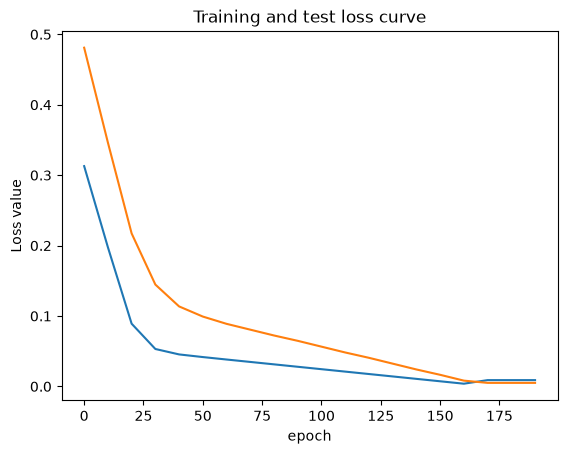

In [44]:
# Plot the loss curve

plt.plot(epoch_count, torch.Tensor(loss_values).numpy(), label="Train loss value")
plt.plot(epoch_count, torch.Tensor(test_loss_values).numpy(), label="Test loss value")
plt.title("Training and test loss curve")
plt.ylabel('Loss value')
plt.xlabel('epoch')

In [35]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

In [36]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

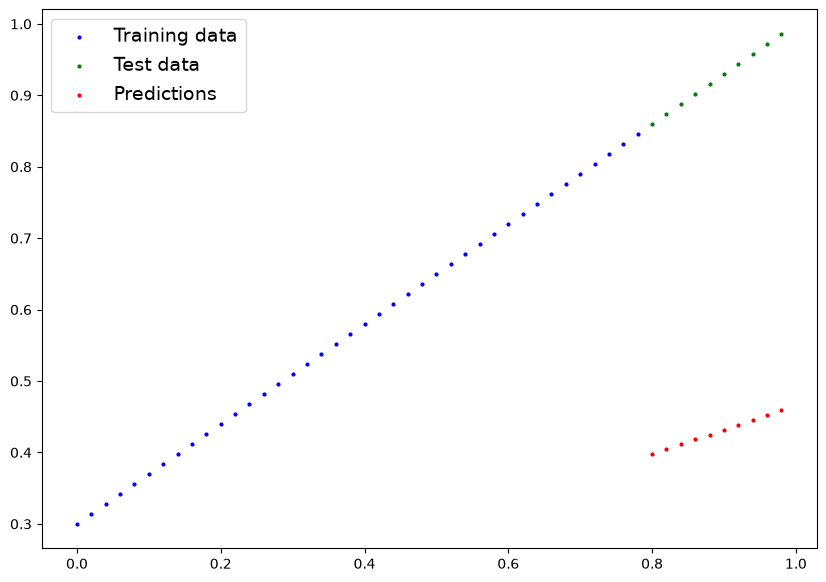

In [37]:
plot_predictions(predictions=y_preds)

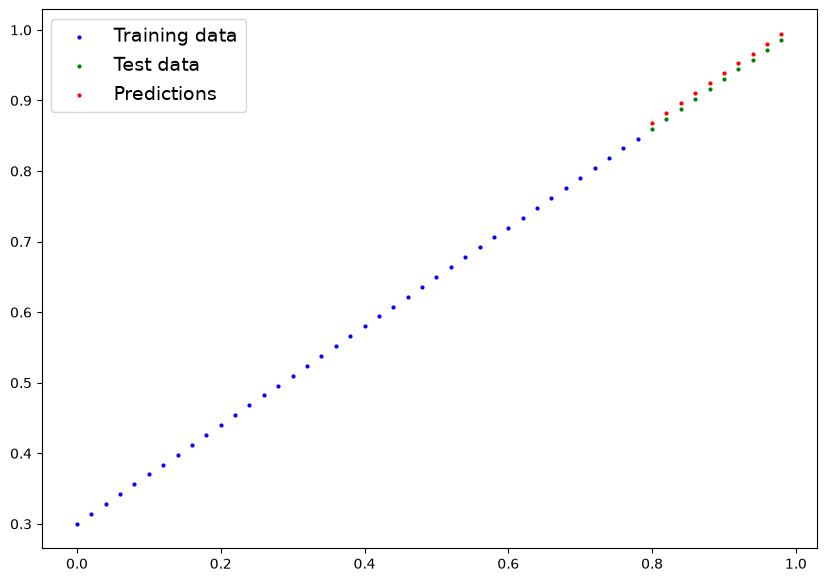

In [38]:
plot_predictions(predictions=y_preds_new)

### Saving my model

There are three method we should know for saving and loading models which had been trained before
https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html

1. `torch.save()` - allow to save a pytorch object in python's pickle format
2. `torch.load()` - allow to load and saved 
3. `torch.nn.Module.load_state_dict()` - allow to load a model's state dictionary

In [46]:
# Saving
from pathlib import Path

#1. Create directory for model
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#2. Create model saved path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"

MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#3. Save a model
print(f'Saving model to: {MODEL_SAVE_PATH}')

torch.save(obj=model_0.state_dict(),
            f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth


### Load the model
After saving this into `models` folder to load the model. I have to create a new instance

In [49]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [50]:
#To load in a saved state_dict

loaded_model_0 = LinearRegressionModel()

#load the state dictionary which had been saved at saved-model step
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [51]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [52]:
# Make some prediction with loaded model

loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_0_preds = loaded_model_0(X_test)



loaded_model_0_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

##6. Time to thong nhat dat nuoccc

Do la step by step de tao nen 1 model gio gom cac `step` do thanh tung block va gom cac block do vao 1 block to nhat

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.13.0+cu130'

Create a device allow to use GPU, if it available. Else using CPU as a default

In [2]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
!nvidia-smi

Mon Aug 17 22:47:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.43.03              KMD Version: 610.43.03     CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650 ...    Off |   00000000:02:00.0 Off |                  N/A |
| N/A   44C    P8              1W /   35W |       8MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 6.1 Prepare Data
Create Y = aX + b with a is hệ số góc b is hệ số tự do =)) tiếng anh do hồi chiều mình bị lỗi bamboo key hihi

In [20]:
weight = 0.7
bias = 0.3

X = torch.arange(0,1,0.02).unsqueeze(dim=1)

y = weight*X + bias

In [21]:
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [22]:
split_size = int(len(X) * 0.8)

X_train, y_train = X[:split_size], y[:split_size]
X_test, y_test = X[split_size:], y[split_size:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [23]:
def plot_predictions(train_data=X_train, train_labels = y_train, test_data=X_test, test_labels=y_test, predictions=None):
    plt.figure(figsize=(10,7))

    plt.scatter(train_data,train_labels, c="b", s=4,label="Training data")

    plt.scatter(test_data, test_labels, c='g', s=4,label="Test data")

    if predictions is not None:
        plt.scatter(test_data, predictions,c="r", s=4, label="Predictions")
    plt.legend(prop={"size": 14});


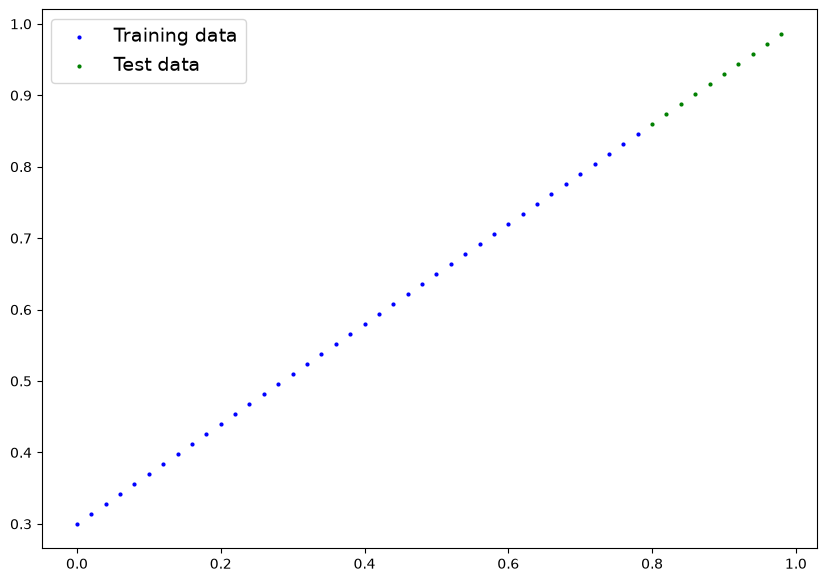

In [24]:
plot_predictions(X_train, y_train, X_test, y_test)

## 6.2 Building a Linear model

In [25]:
class LinearRegressionModelV2(nn.Module):

    def __init__(self):
        super().__init__()
        # Use nn.Linear()
        self.linear_layer = nn.Linear(in_features=1, 
                                        out_features=1)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)


# Set manual seed as 42

torch.manual_seed(42)

model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()


(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [26]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [27]:
#Check which device is using 
next(model_1.parameters()).device

device(type='cpu')

In [28]:
#Set model to use target device (gpu or cpu) to compute
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

## 6.3 Training
Huấn luyện mô hình:
* Loss func
* Optimizer
* Traning loop
* Testing loop

In [29]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01, )

In [30]:
torch.manual_seed(42)

epochs = 200

#Put data to device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs): 
    model_1.train()
    ### training

    #1. do forward pass
    y_pred = model_1(X_train)
    
    #2. Calculate the loss
    loss = loss_fn(y_pred, y_train)

    #3. Optimizer
    optimizer.zero_grad()

    #4. backward
    loss.backward()

    #5 optimize step 
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        #1 do forward pass
        test_pred = model_1(X_test)

        #2. calculate the loss
        test_loss = loss_fn(test_pred, y_test)

        #Print information


        if epoch % 10 == 0:
            print(f'Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}')





Epoch: 0 | Loss: 0.5551779270172119 | Test Loss: 0.5739762187004089
Epoch: 10 | Loss: 0.4399681091308594 | Test Loss: 0.4392664134502411
Epoch: 20 | Loss: 0.3247582018375397 | Test Loss: 0.30455657839775085
Epoch: 30 | Loss: 0.20954833924770355 | Test Loss: 0.16984669864177704
Epoch: 40 | Loss: 0.09433844685554504 | Test Loss: 0.03513690456748009
Epoch: 50 | Loss: 0.023886388167738914 | Test Loss: 0.04784907028079033
Epoch: 60 | Loss: 0.019956795498728752 | Test Loss: 0.045803118497133255
Epoch: 70 | Loss: 0.016517987474799156 | Test Loss: 0.037530567497015
Epoch: 80 | Loss: 0.013089174404740334 | Test Loss: 0.02994490973651409
Epoch: 90 | Loss: 0.009653178043663502 | Test Loss: 0.02167237363755703
Epoch: 100 | Loss: 0.006215683650225401 | Test Loss: 0.014086711220443249
Epoch: 110 | Loss: 0.00278724217787385 | Test Loss: 0.005814164876937866
Epoch: 120 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 130 | Loss: 0.0012645035749301314 | Test Loss: 0.01380180101841

In [31]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

### 6.4 Making and  evaluating prediction

In [32]:
model_1.eval()
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds    

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

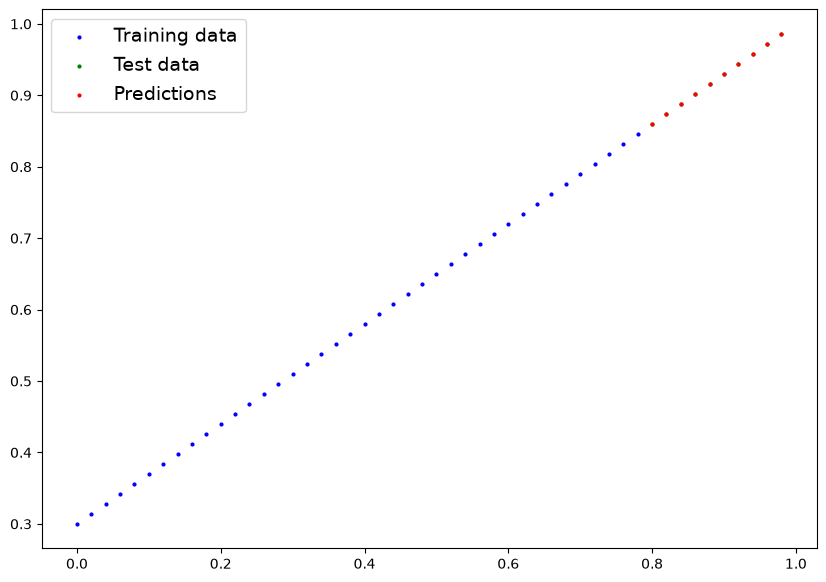

In [34]:
plot_predictions(predictions=y_preds.cpu())

### 6.5 Saving and load model

# Saving
from pathlib import Path

#1. Create directory for model
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#2. Create model saved path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"

MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#3. Save a model
print(f'Saving model to: {MODEL_SAVE_PATH}')

torch.save(obj=model_0.state_dict(),
            f=MODEL_SAVE_PATH)

In [35]:
from pathlib import Path

MODEL_PATH = Path("models")

MODEL_PATH.mkdir(parents=True, exist_ok = True)

MODEL_NAME = "01_pytorch_workflow_model_1.pth"

MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
print(f'Saving model to {MODEL_SAVE_PATH}')

torch.save(obj=model_1.state_dict(), f=MODEL_SAVE_PATH)


Saving model to models/01_pytorch_workflow_model_1.pth


## 6.5 Load model

In [36]:
#Load model
# 1. Make a new instance
loaded_model_1 = LinearRegressionModelV2()

#2. Load state_dict()

loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

#3. Put the target model to device

loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [37]:
next(loaded_model_1.parameters()).to(device)

Parameter containing:
tensor([[0.6968]], device='cuda:0', requires_grad=True)

In [38]:
# Evalue the loaded model

loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')